In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load feature engineered dataset
df = pd.read_csv('data/diabetic_data_features.csv')

# Separate features and target
X = df.drop('readmitted', axis=1)
y = df['readmitted']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.1f}:1")

Features shape: (71515, 36)
Target shape: (71515,)

Target distribution:
readmitted
0    65222
1     6293
Name: count, dtype: int64

Class imbalance ratio: 10.4:1


In [3]:
# Split data into train and test sets
# We split BEFORE applying SMOTE to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducibility
    stratify=y          # maintain class ratio in both splits
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (57212, 36)
Testing set shape: (14303, 36)

Training target distribution:
readmitted
0    52178
1     5034
Name: count, dtype: int64

Testing target distribution:
readmitted
0    13044
1     1259
Name: count, dtype: int64


In [4]:
# Apply SMOTE only on training data - NEVER on test data
# This prevents data leakage

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE applied successfully!")
print(f"\nBefore SMOTE:")
print(f"  Class 0: {y_train.value_counts()[0]}")
print(f"  Class 1: {y_train.value_counts()[1]}")
print(f"\nAfter SMOTE:")
print(f"  Class 0: {y_train_smote.value_counts()[0]}")
print(f"  Class 1: {y_train_smote.value_counts()[1]}")
print(f"\nNew training set shape: {X_train_smote.shape}")

SMOTE applied successfully!

Before SMOTE:
  Class 0: 52178
  Class 1: 5034

After SMOTE:
  Class 0: 52178
  Class 1: 52178

New training set shape: (104356, 36)


In [5]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train all models and store results
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc
    }
    print(f"  ✅ Done! ROC-AUC: {roc_auc:.4f}")

print("\nAll models trained successfully!")

Training Logistic Regression...
  ✅ Done! ROC-AUC: 0.5434
Training Decision Tree...
  ✅ Done! ROC-AUC: 0.5229
Training Random Forest...
  ✅ Done! ROC-AUC: 0.5980
Training XGBoost...
  ✅ Done! ROC-AUC: 0.6254

All models trained successfully!


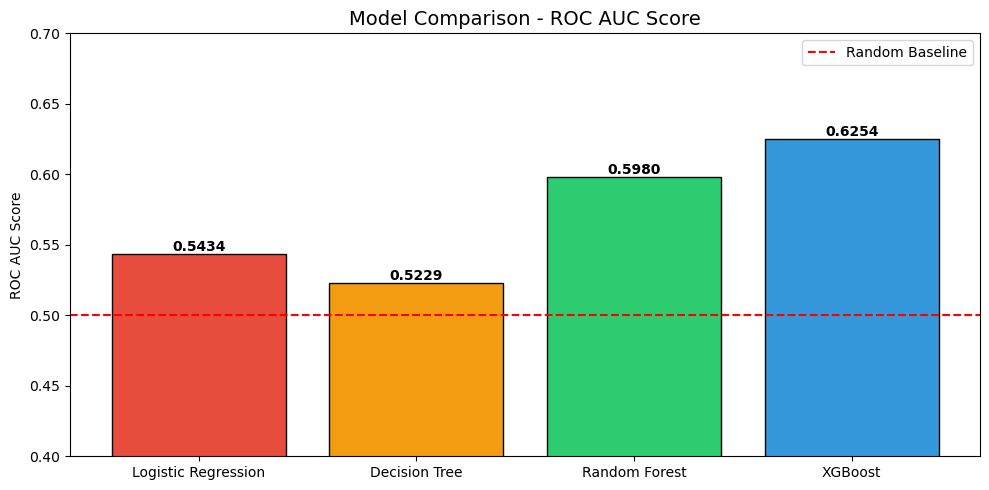

Plot saved!


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
aucs = [results[name]['roc_auc'] for name in names]
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

bars = ax.bar(names, aucs, color=colors, edgecolor='black')
ax.set_title('Model Comparison - ROC AUC Score', fontsize=14)
ax.set_ylabel('ROC AUC Score')
ax.set_ylim(0.4, 0.7)
ax.axhline(y=0.5, color='red', linestyle='--', label='Random Baseline')

for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

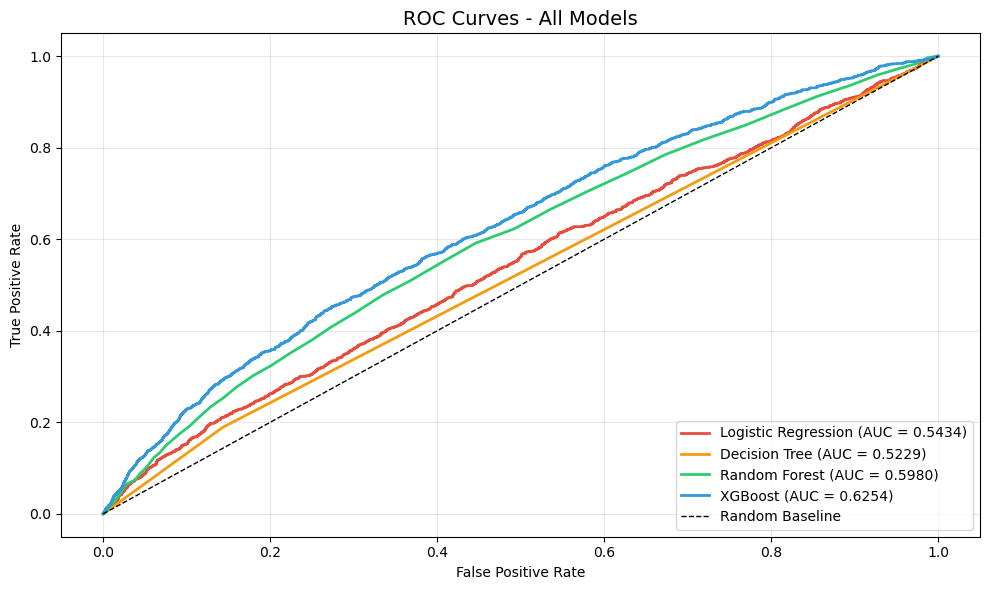

Plot saved!


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

for (name, result), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {result['roc_auc']:.4f})")

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')

ax.set_title('ROC Curves - All Models', fontsize=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

In [8]:
# XGBoost is our best model - let's get detailed metrics
best_model = results['XGBoost']

print("=" * 55)
print("XGBOOST - DETAILED CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, best_model['y_pred'],
                            target_names=['Not Readmitted', 'Readmitted <30']))

print(f"\nROC-AUC Score: {best_model['roc_auc']:.4f}")

XGBOOST - DETAILED CLASSIFICATION REPORT
                precision    recall  f1-score   support

Not Readmitted       0.91      0.99      0.95     13044
Readmitted <30       0.21      0.03      0.05      1259

      accuracy                           0.90     14303
     macro avg       0.56      0.51      0.50     14303
  weighted avg       0.85      0.90      0.87     14303


ROC-AUC Score: 0.6254


In [9]:
# Try different thresholds and find the best one
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

from sklearn.metrics import precision_score, recall_score, f1_score

for thresh in thresholds:
    y_pred_thresh = (best_model['y_prob'] >= thresh).astype(int)
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    print(f"{thresh:<12} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.1          0.1153       0.6148       0.1941      
0.2          0.1646       0.2915       0.2104      
0.3          0.1926       0.1398       0.1620      
0.4          0.2090       0.0667       0.1011      
0.5          0.2069       0.0286       0.0502      


In [10]:
# Apply best threshold of 0.2
best_threshold = 0.2
y_pred_final = (best_model['y_prob'] >= best_threshold).astype(int)

print("=" * 55)
print("XGBOOST - FINAL MODEL (Threshold = 0.2)")
print("=" * 55)
print(classification_report(y_test, y_pred_final,
                            target_names=['Not Readmitted', 'Readmitted <30']))
print(f"ROC-AUC Score: {best_model['roc_auc']:.4f}")

XGBOOST - FINAL MODEL (Threshold = 0.2)
                precision    recall  f1-score   support

Not Readmitted       0.93      0.86      0.89     13044
Readmitted <30       0.16      0.29      0.21      1259

      accuracy                           0.81     14303
     macro avg       0.55      0.57      0.55     14303
  weighted avg       0.86      0.81      0.83     14303

ROC-AUC Score: 0.6254


In [12]:
import joblib

# Save the best model
joblib.dump(results['XGBoost']['model'], 'models/xgboost_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [13]:
print("=" * 55)
print("MODULE 5 - MODEL BUILDING SUMMARY")
print("=" * 55)
print("""
Models Trained:
-----------------------------------------------------
1. Logistic Regression  → ROC-AUC: 0.5434
2. Decision Tree        → ROC-AUC: 0.5229
3. Random Forest        → ROC-AUC: 0.5980
4. XGBoost              → ROC-AUC: 0.6254 🏆

Best Model: XGBoost
Best Threshold: 0.2
Final Recall: 29% (up from 3%)
Final F1: 0.21 (up from 0.05)

Key Decisions:
-----------------------------------------------------
✅ SMOTE applied to handle class imbalance
✅ Stratified train/test split
✅ Threshold tuned for clinical relevance
✅ Recall prioritized over precision
-----------------------------------------------------
Ready for Module 6 - Model Evaluation & Explainability!
""")

MODULE 5 - MODEL BUILDING SUMMARY

Models Trained:
-----------------------------------------------------
1. Logistic Regression  → ROC-AUC: 0.5434
2. Decision Tree        → ROC-AUC: 0.5229
3. Random Forest        → ROC-AUC: 0.5980
4. XGBoost              → ROC-AUC: 0.6254 🏆

Best Model: XGBoost
Best Threshold: 0.2
Final Recall: 29% (up from 3%)
Final F1: 0.21 (up from 0.05)

Key Decisions:
-----------------------------------------------------
✅ SMOTE applied to handle class imbalance
✅ Stratified train/test split
✅ Threshold tuned for clinical relevance
✅ Recall prioritized over precision
-----------------------------------------------------
Ready for Module 6 - Model Evaluation & Explainability!

